In [ ]:
import numpy as np
 
# sigmoid function
def nonlin(x,deriv=False):
    if deriv:
        return x*(1-x)
    return 1/(1+np.exp(-x))
 
 
# input dataset
X = np.array([  [0,0,1],
    [0,1,1],
    [1,0,1],
    [1,1,1] ])
 
# output dataset           
y = np.array([[0,0,1,1]]).T
 
# seed random numbers to make calculation
# deterministic (just a good practice)
np.random.seed(1)
 
# initialize weights randomly with mean 0
syn0 = 2*np.random.random((3,1)) - 1
growth = {"error1": [], "error2": [], "delta" : [], "res" : syn0}
for iter in range(10_000):
    
    # forward propagation
    l0 = X
    l1 = nonlin(np.dot(l0,syn0))
    
    # how much did we miss?
    l1_error = y - l1
    
    rms_error = np.mean(np.sqrt((l1-y)**2))
    rms_error2 = np.mean(np.sqrt(l1_error**2))
    growth['error1'].append(rms_error)
    growth['error2'].append(rms_error2)
    
    # multiply how much we missed by the
    # slope of the sigmoid at the values in l1
    l1_delta = l1_error * nonlin(l1,True)
    growth['delta'].append(l1_delta)
    # update weights
    syn0 += np.dot(l0.T,l1_delta)
    # growth['res'].append(syn0)
    
print("Output After Training:")
print(l1)

Output After Training:
[[0.00966449]
 [0.00786506]
 [0.99358898]
 [0.99211957]]


In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


In [22]:
# the error aggregation starts here
x_range = np.linspace(-10, 10, 20, dtype=np.float32)
y_range = np.linspace(-10, 10, 20, dtype=np.float32)
errors = []
for _x in x_range:
    syn0[0] = _x
    for _y in y_range:
        syn0[1] = _y

        # apply the model to the input
        layer_0 = X
        layer_1 = nonlin(np.dot(layer_0, syn0))

        # evaluate the error using the RMSE
        error = np.mean(np.sqrt((layer_1 - y) ** 2))
        errors.append(error)


error_surface = np.reshape(np.array(growth['error1']), (x_range.shape[0], y_range.shape[0]))
_X, _Y = np.meshgrid(x_range, y_range, indexing='ij')

ValueError: cannot reshape array of size 10000 into shape (20,20)

TypeError: Axes3D.plot_surface() missing 2 required positional arguments: 'Y' and 'Z'

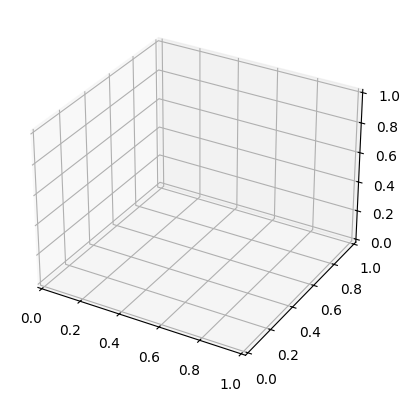

In [16]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(growth['delta'], cmap=cm.YlOrBr_r, edgecolor='gray', linewidth=0.004, antialiased=False)
plt.show()